In [1]:
%matplotlib widget
import torch
import numpy as np
import matplotlib.pyplot as plt
from diffSPH.dataLoader import *
from diffSPH.plotting import visualizeParticles, updatePlot

In [2]:
folders = [
        #   '/home/winchenbach/dev/diffSPH16K/data/compressible/circularRegion/',
        #    '/home/winchenbach/dev/diffSPH16K/data/compressible/dualRegion/',
        #    '/home/winchenbach/dev/diffSPH16K/data/compressible/pressureDensity/',
        #    '/home/winchenbach/dev/diffSPH16K/data/compressible/quadRegion/',
           '/home/winchenbach/dev/diffSPH16K/data/compressible/velocity/',

        #    '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleFreeSlip/both/',
        #    '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleFreeSlip/domain/',
        #    '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleFreeSlip/noBoundary/',
        #    '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleFreeSlip/obstacle/',
         #   '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleFreeSlip/TGV/',

        #    '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleNoSlip/both/'
        #    '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleNoSlip/domain/',
        #    '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleNoSlip/noBoundary/',
        #    '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleNoSlip/obstacle/',
         #   '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleNoSlip/TGV/',

        #    '/home/winchenbach/servus05/dev/datasets_ssd/weaklyCompressible2/freeSlipTGV/data/',
        #    '/home/winchenbach/servus05/dev/datasets_ssd/weaklyCompressible2/noSlipTGV/data/',
        # '/home/winchenbach/servus05/dev/datasets_ssd/weaklyCompressible/freeSlipv2/data/',
        # '/home/winchenbach/dev/diffSPH_public/simulationScripts/data/'
]

In [3]:
configuration = DataConfiguration(
    frameDistance=1,
    frameSpacing=1,
    maxRollout=1,
    historyLength=1,
    skipInitialFrames=0,
    cutoff=0
)

processed = []

for folder in folders:
    p = processFolder(folder, configuration)
    processed.extend(p)
# processed = processFolder(folders[0], configuration)

for file in processed:
    print(f'File: {file["fileName"]}, FrameCount: {len(file["frames"])}, Samples: {len(file["samples"])}, Style: {file["style"]}, Number of samples: {len(processed[0]["samples"])}, first sample: {processed[0]["samples"][0]}, last sample: {processed[0]["samples"][-1]}')


File: /home/winchenbach/dev/diffSPH16K/data/compressible/velocity//velocityNoise_16384_1350991724_2025-08-13_16-51-14_6.h5, FrameCount: 4095, Samples: 4095, Style: diffSPH, Number of samples: 4095, first sample: 000001, last sample: 004095
File: /home/winchenbach/dev/diffSPH16K/data/compressible/velocity//velocityNoise_16384_145652384_2025-08-13_16-19-44_7.h5, FrameCount: 4095, Samples: 4095, Style: diffSPH, Number of samples: 4095, first sample: 000001, last sample: 004095
File: /home/winchenbach/dev/diffSPH16K/data/compressible/velocity//velocityNoise_16384_1747215154_2025-08-13_15-54-36_3.h5, FrameCount: 4095, Samples: 4095, Style: diffSPH, Number of samples: 4095, first sample: 000001, last sample: 004095
File: /home/winchenbach/dev/diffSPH16K/data/compressible/velocity//velocityNoise_16384_1832541251_2025-08-13_15-40-19_4.h5, FrameCount: 4095, Samples: 4095, Style: diffSPH, Number of samples: 4095, first sample: 000001, last sample: 004095
File: /home/winchenbach/dev/diffSPH16K/da

In [4]:
dataset, datasetLoader = getDataLoader(processed, 4, shuffle = True)
datasetIter = iter(datasetLoader)

nextData = next(datasetIter)
print(f'Next data: {nextData}')

# nextData = [0, 16, 64, 98]
# nextData = [9000]

Next data: [27834, 8954, 8794, 47148]


In [5]:
import ipywidgets

dropdownFiles = ipywidgets.Dropdown(
    options=[f['fileName'] for f in processed],
    description='Files:',
    disabled=False,
    style={'description_width': 'initial'},
    layout=ipywidgets.Layout(width='50%'),
    value=processed[0]['fileName']  # Default value
)
frameSlider = ipywidgets.IntSlider(
    value=0,
    min=0,
    max=len(processed[0]['frames']) - 1,
    step=1,
    description='Frame:',
    continuous_update=False,
    style={'description_width': 'initial'},
    layout=ipywidgets.Layout(width='50%')
)

def updatePlots(plots, processed, frame):
    priorStates, currentState, trajectoryStates, domains, rotMats, configs, neighborhoods = loadAugmentedBatch(
        dataset, [(processed['fileName'],'%06d'%frame)], configuration, device = 'cuda', dtype = torch.float32,
        augmentAngle = False,
    )
    # s = 1

    updatePlot(plots[0], currentState, quantity=currentState.densities, domain = domains[0], markerSize = s)
    updatePlot(plots[1], currentState, quantity=currentState.internalEnergies if isinstance(currentState, CompressibleSPHState) else currentState.velocities, domain = domains[0], markerSize = s)
    updatePlot(plots[2], currentState, quantity=currentState.velocities, domain = domains[0], markerSize = s)
    updatePlot(plots[3], currentState, quantity=currentState.UIDs, domain = domains[0], markerSize = s)
    
    fig.suptitle(f'File: {processed["fileName"].split("/")[-1]}, Frame: {processed["frames"][frame]}, Samples: {len(processed["samples"])}, Style: {processed["style"]}, \nNumber of samples: {len(processed["samples"])}, first sample: {processed["samples"][0]}, last sample: {processed["samples"][-1]}')


def updatePlotFromDropdown(change):
    if change['new'] is not None:
        fileIndex = [f['fileName'] for f in processed].index(change['new'])
        frames = processed[fileIndex]['frames']

        priorFrames = int(frameSlider.max)
        newValue = np.clip(int(frameSlider.value / priorFrames * (len(frames) - 1)), 0, len(frames) - 1)
        frameSlider.max = len(frames) - 1
        frameSlider.value = newValue
        fig.suptitle(f'File: {change["new"].split("/")[-1]}, Frame: {frames[0]}, Samples: {len(processed[fileIndex]["samples"])}, Style: {processed[fileIndex]["style"]}, \nNumber of samples: {len(processed[fileIndex]["samples"])}, first sample: {processed[fileIndex]["samples"][0]}, last sample: {processed[fileIndex]["samples"][-1]}')
        updatePlots(plots, processed[fileIndex], frame=frameSlider.value)


def updatePlotFromSlider(change):
    if change['new'] is not None:
        fileIndex = [f['fileName'] for f in processed].index(dropdownFiles.value)
        updatePlots(plots, processed[fileIndex], frame=change['new'])


dropdownFiles.observe(updatePlotFromDropdown, names='value')
frameSlider.observe(updatePlotFromSlider, names='value')


Dropdown(description='Files:', layout=Layout(width='50%'), options=('/home/winchenbach/dev/diffSPH16K/data/com…

IntSlider(value=0, continuous_update=False, description='Frame:', layout=Layout(width='50%'), max=4094, style=…

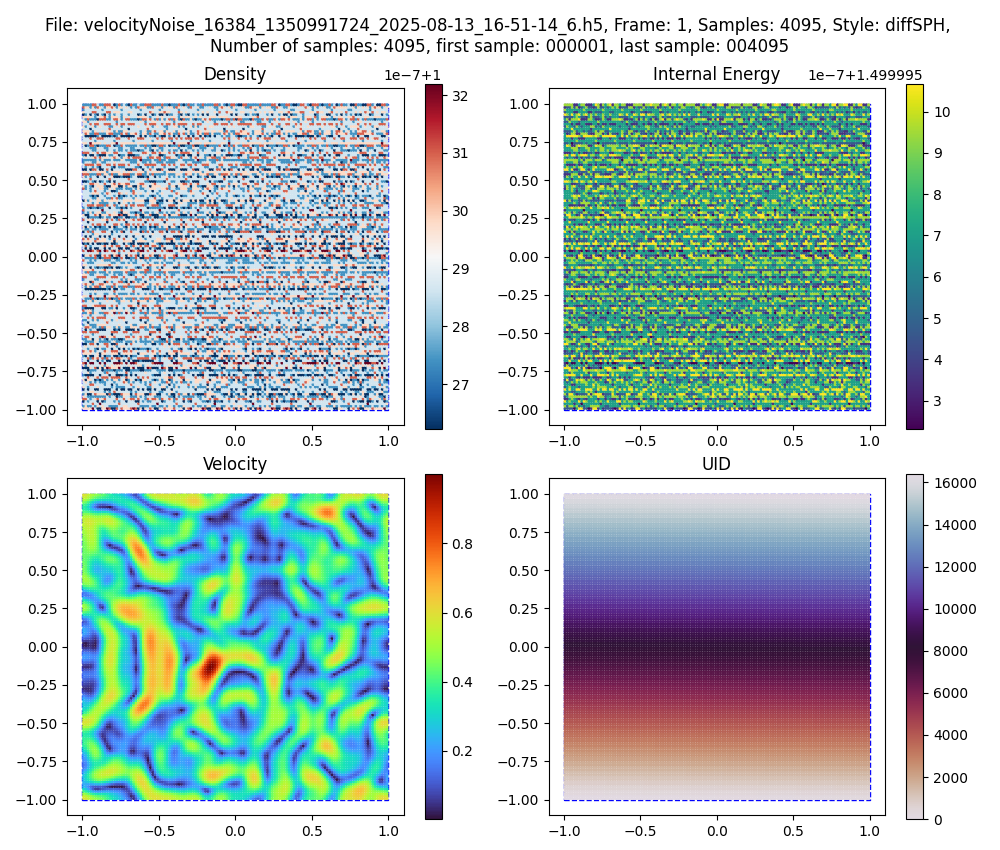

In [6]:
priorStates, currentState, trajectoryStates, domains, rotMats, configs, neighborhoods = loadAugmentedBatch(
    dataset, [(processed[0]['fileName'],'%06d'%0)], configuration, device = 'cuda', dtype = torch.float32,
    augmentAngle = False,
)

fig, axis = plt.subplots(2, 2, figsize=(10, 8.5), squeeze = False)
# filteredNeighborhood = filterNeighborhoodByKind(currentStates[0], neighborhoods[0], 'noghost')

plots = []
axes = axis.flatten()

s = 1.5

densityPlot = visualizeParticles(fig, axes[0],
                            particles = currentState,
                            domain = domains[0],
                            quantity = currentState.densities,
                            which = 'both',
                            mapping = 'L2',
                            cmap = 'RdBu_r',
                            visualizeBoth=True,
                            kernel = kernelNameToKernel(configs[0]['kernel']),
                            plotDomain = True,
                            gridVisualization=False, markerSize=s,
                            batch = 0, streamLines = False, title = 'Density')
energyPlot = visualizeParticles(fig, axes[1],
                            particles = currentState,
                            domain = domains[0],
                            quantity = currentState.internalEnergies if isinstance(currentState, CompressibleSPHState) else currentState.velocities,
                            which = 'both',
                            mapping = '.x',
                            cmap = 'viridis' if isinstance(currentState, CompressibleSPHState) else 'RdBu_r',
                            visualizeBoth=True,
                            kernel = kernelNameToKernel(configs[0]['kernel']),
                            plotDomain = True,
                            gridVisualization=False, markerSize=s,
                            batch = 0, streamLines = False, title = 'Internal Energy' if isinstance(currentState, CompressibleSPHState) else 'Velocity X')
velocityPlot = visualizeParticles(fig, axes[2],
                            particles = currentState,
                            domain = domains[0],
                            quantity = currentState.velocities,
                            which = 'both',
                            mapping = 'L2' if isinstance(currentState, CompressibleSPHState) else '.y',
                            cmap = 'turbo' if isinstance(currentState, CompressibleSPHState) else 'RdBu_r',
                            visualizeBoth=True,
                            kernel = kernelNameToKernel(configs[0]['kernel']),
                            plotDomain = True,
                            gridVisualization=False, markerSize=s,
                            batch = 0, streamLines = False, title = 'Velocity' if isinstance(currentState, CompressibleSPHState) else 'Velocity Y')
UIDPlot = visualizeParticles(fig, axes[3],
                            particles = currentState,
                            domain = domains[0],
                            quantity = currentState.UIDs,
                            which = 'both',
                            mapping = 'L2',
                            cmap = 'twilight_r',
                            visualizeBoth=True,
                            kernel = kernelNameToKernel(configs[0]['kernel']),
                            plotDomain = True,
                            gridVisualization=False, markerSize=s,
                            batch = 0, streamLines = False, title = 'UID')


fig.suptitle(f'File: {processed[0]["fileName"].split("/")[-1]}, Frame: {processed[0]["frames"][0]}, Samples: {len(processed[0]["samples"])}, Style: {processed[0]["style"]}, \nNumber of samples: {len(processed[0]["samples"])}, first sample: {processed[0]["samples"][0]}, last sample: {processed[0]["samples"][-1]}')
plots = [densityPlot, energyPlot, velocityPlot, UIDPlot]

fig.tight_layout()

display(dropdownFiles)
display(frameSlider)

In [7]:
priorStates, currentState, trajectoryStates, domains, rotMats, configs, neighborhoods = loadAugmentedBatch(
        dataset, [(dropdownFiles.value,'%06d'% frameSlider.value)], configuration, device = 'cuda', dtype = torch.float32,
        augmentAngle = False,
    )

In [8]:
currentState.pressures

tensor([1., 1., 1.,  ..., 1., 1., 1.], device='cuda:0')

In [9]:
from diffSPH.dataLoaderUtils.resume import stateToState

In [10]:
state, particleSystem, config, domain, wrappedKernel, simulator, SimulationSystem, integrator, dt = stateToState(currentState, configs, domains, batch=0)

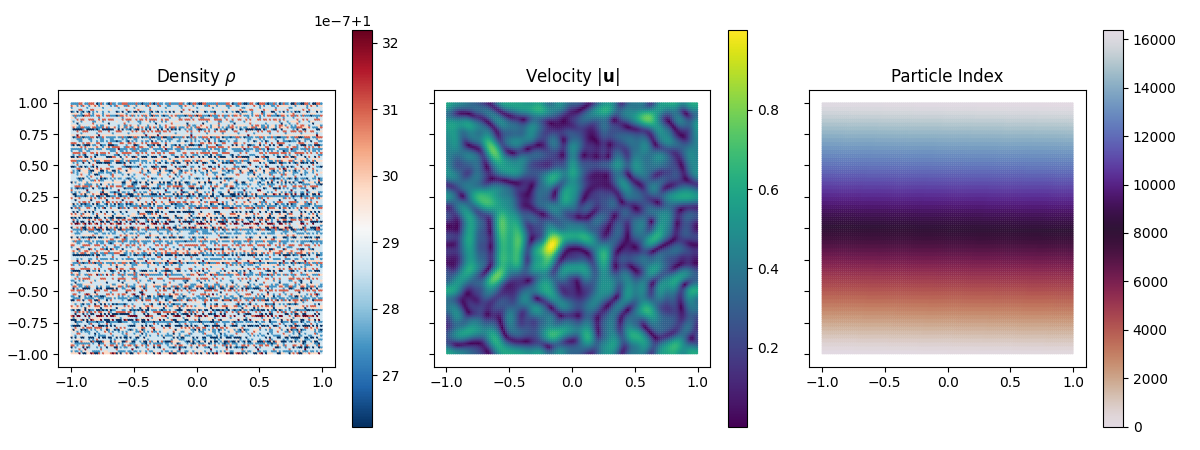

In [11]:
from tqdm import TqdmExperimentalWarning
import warnings
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm
import math

fig, axis = plt.subplots(1, 3, figsize=(12, 4.5), squeeze=False, sharex=True, sharey=True)

markerSize = 1
fluidParticles = particleSystem.systemState
densityPlot = visualizeParticles(fig, axis[0,0], particles = fluidParticles, quantity = fluidParticles.densities, domain = domain, which = 'fluid', visualizeBoth=False, kernel = config['kernel'], plotDomain = False, cmap = 'RdBu_r', title='Density $\\rho$', markerSize = markerSize)
velocityPlot = visualizeParticles(fig, axis[0,1], particles = fluidParticles, quantity = fluidParticles.velocities, domain = domain, which = 'fluid', visualizeBoth=False, kernel = config['kernel'], plotDomain = False, cmap = 'viridis', title='Velocity $|\\mathbf{u}|$', markerSize = markerSize, mapping = 'L2')
UIDPlot = visualizeParticles(fig, axis[0,2], particles = fluidParticles, quantity = fluidParticles.UIDs, domain = domain, which = 'fluid', visualizeBoth=False, kernel = config['kernel'], plotDomain = False, cmap = 'twilight_r', title='Particle Index', markerSize = markerSize)

# fig.suptitle(f'{config["caseName"]}, ptcls = {state.positions.shape[0]}, kernel = {config["kernel"].name}, neighbors = {config["targetNeighbors"]:.2g}, $c_s$ = {config["fluid"]["c_s"]:.1f}')
fig.tight_layout()

In [12]:
timeLimit = 4
timesteps = math.ceil(timeLimit / dt)
fps = 50

exportInterval = 1 / fps
plotInterval = int(math.ceil(exportInterval / dt))
timesteps = int(timeLimit / dt)

In [13]:
display(int(config['domain'].dim))

2

In [14]:
for i in (tq:=tqdm(range(timesteps))):
    particleSystem, currentState, updates = integrator.function(particleSystem, dt, simulator, config, priorStep = particleSystem.priorStep)
    particleSystem.priorStep = [updates[-1], currentState[-1]]
    if (i % plotInterval == 0 and i > 0) or i == timesteps - 1:
        updatePlot(densityPlot, particleSystem.systemState, particleSystem.systemState.densities)
        updatePlot(velocityPlot, particleSystem.systemState, particleSystem.systemState.velocities)
        updatePlot(UIDPlot, particleSystem.systemState, particleSystem.systemState.UIDs)
        
        fig.canvas.draw()
        fig.canvas.flush_events()

  0%|          | 0/4000 [00:00<?, ?it/s]